In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
import h5py
import numpy as np
import scipy.signal

def boxcar_kernel(width):
    width = int(round(width, 0))
    return np.ones(width, dtype="float32") / np.sqrt(width)

def find_burst(ts, min_width=1, max_width=128):
    widths = list(range(int(min_width), min(int(max_width) + 1, len(ts) - 2)))
    snrs = np.empty_like(widths, dtype=float)
    peaks = np.empty_like(widths, dtype=int)
    for i, w in enumerate(widths):
        convolved = scipy.signal.convolve(ts, boxcar_kernel(w), mode="same")
        peaks[i] = np.nanargmax(convolved)
        snrs[i] = convolved[peaks[i]]
    best_idx = np.nanargmax(snrs)
    return peaks[best_idx], widths[best_idx], snrs[best_idx]

def bin_freq_channels(data, fbin_factor=16):
    n_chan, n_time = data.shape
    return np.nanmean(
        data[:(n_chan // fbin_factor) * fbin_factor]
        .reshape(-1, fbin_factor, n_time),
        axis=1
)

def load_wfall(file_path: str, fbin_factor: int = 128) -> np.ndarray:
    """
    Load and preprocess a single .h5 file into a (N, t) array
    where N = freq bins, t = time steps.
    """
    with h5py.File(file_path, "r") as f:
        wfall = f["data"][:]
        good_freq = f["good_freq"][:]

    # Mask bad frequencies
    wfall[~good_freq, :] = np.nan

    # Bin frequency channels → shape (N, t)
    wfall_binned = bin_freq_channels(wfall, fbin_factor)

    # Replace NaNs with median (same as your plot code)
    wfall_binned[np.isnan(wfall_binned)] = np.nanmedian(wfall_binned)

    return wfall_binned  # (N, t)


def normalize(wfall: np.ndarray) -> np.ndarray:
    mean = wfall.mean(axis=1, keepdims=True)
    std  = wfall.std(axis=1, keepdims=True) + 1e-8
    return (wfall - mean) / std


class FRBDataset(Dataset):
    def __init__(
        self,
        file_paths,
        labels,     # 0 = non-repeater, 1 = repeater
        fbin_factor,
        t_size
    ):
        self.file_paths = file_paths
        self.labels = labels
        self.fbin_factor = fbin_factor
        self.t_size = t_size

    def __len__(self):
        return len(self.file_paths)

    def center(self, wfall):
        n, t = wfall.shape
        if t >= self.t_size:
            # Center crop around the burst peak
            ts = wfall.sum(axis=0)
            peak, _, _ = find_burst(ts)
            start = max(0, peak - self.t_size // 2)
            start = min(start, t - self.t_size)
            return wfall[:, start : start + self.t_size]
        else:
            
            print("padding")
            # Pad with median value on the right
            pad = np.full((n, self.t_size - t), np.median(wfall))
            return np.concatenate([wfall, pad], axis=1)

    def __getitem__(self, idx):
        wfall = load_wfall(self.file_paths[idx], self.fbin_factor)  # (N, t)
        wfall = self.center(wfall)                                   # (N, t_size)
        wfall = normalize(wfall)                                     # (N, t_size)

        # Shape: (N, t_size) — each row is one x_i fed to the 1D-CNN
        x = torch.tensor(wfall, dtype=torch.float32)
        y = torch.tensor(self.labels[idx], dtype=torch.long)
        return x, y

/tmp/ipykernel_28420/3242329043.py:24: RuntimeWarning: Mean of empty slice
  return np.nanmean(


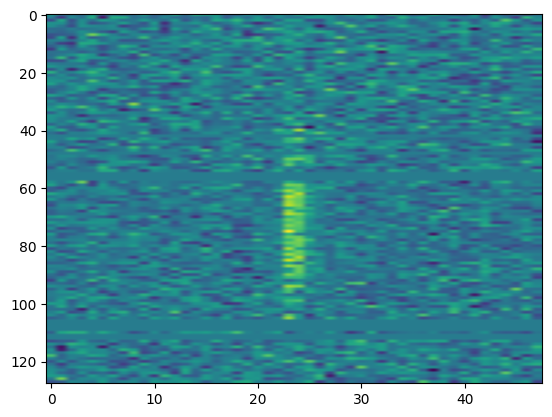

In [4]:
dataset = FRBDataset(
    file_paths=["FRB20180725A_stokesi_dynamic_spectrum.h5"],
    labels=[1],
    fbin_factor=128,
    t_size=48,
)
loader = DataLoader(dataset, batch_size=16, shuffle=True, num_workers=4)

dataset.__getitem__(0)[0]

#plot wfall
dataset.__getitem__(0)[0]

import matplotlib.pyplot as plt

plt.imshow(dataset.__getitem__(0)[0], aspect='auto')